[STEP 1: MVD - Core Logic Check]
Features: ['stenosis_severity', 'ffr_true']. Data shape: (500, 2)
   stenosis_severity  ffr_true
0           0.524724  0.737638
1           0.870429  0.564786
2           0.739196  0.630402
3           0.659195  0.670402
4           0.393611  0.803194


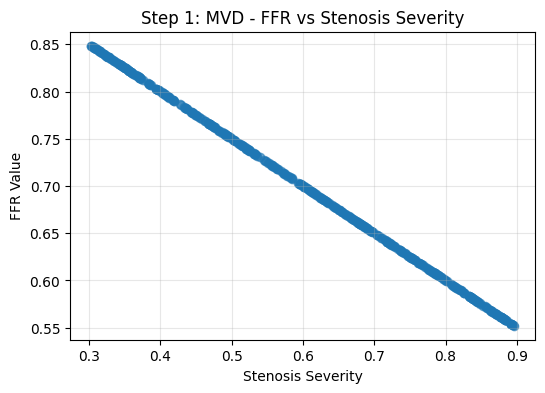

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Constants
N_SAMPLES = 500
np.random.seed(42)

# FFR Simulation Logic (Simplified)
def calculate_ffr_simple(df):
    # FFR = 1.0 - (Severity * 0.5)
    return 1.0 - (df['stenosis_severity'] * 0.5)

# Step 1 - Execution
print("[STEP 1: MVD - Core Logic Check]")

# 1. Generate the single feature
df1 = pd.DataFrame({
    'stenosis_severity': np.random.uniform(0.3, 0.9, N_SAMPLES)
})

# 2. Calculate the FFR label
df1['ffr_true'] = calculate_ffr_simple(df1)
df1['ffr_true'] = np.clip(df1['ffr_true'], 0.4, 1.0)

print(f"Features: {list(df1.columns)}. Data shape: {df1.shape}")
print(df1.head())

# 3. Plot the result
plt.figure(figsize=(6, 4))
plt.scatter(df1['stenosis_severity'], df1['ffr_true'], alpha=0.6)
plt.title("Step 1: MVD - FFR vs Stenosis Severity")
plt.xlabel("Stenosis Severity")
plt.ylabel("FFR Value")
plt.grid(alpha=0.3)
plt.show()


1. Sanity Range Check:
count    500.000000
mean       0.700431
std        0.089607
min        0.552111
25%        0.623163
50%        0.696051
75%        0.777616
max        0.848482
Name: ffr_true, dtype: float64
   PASS: FFR values are within the expected clinical range (0.4 to 1.0).

2. Monotonic Bin Check:
stenosis_severity
(0.302, 0.402]    0.826254
(0.402, 0.501]    0.772687
(0.501, 0.599]    0.726850
(0.599, 0.698]    0.674654
(0.698, 0.797]    0.624268
(0.797, 0.896]    0.574243
Name: ffr_true, dtype: float64
   PASS: Mean FFR decreases monotonically across severity bins.

3. Stress Test (Varying Stenosis):


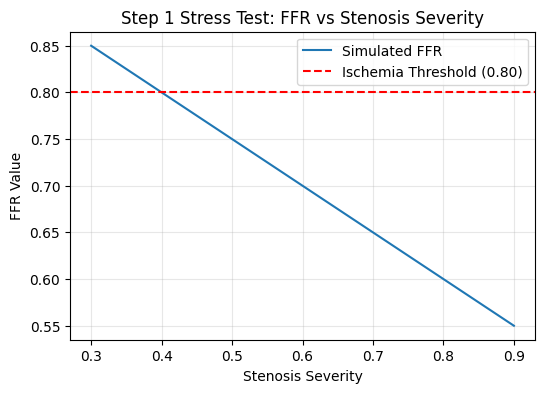

   PASS: Stress test plot confirms expected inverse linear relationship.


In [21]:
# 1. Sanity Range Check
print("\n1. Sanity Range Check:")
print(df1['ffr_true'].describe())
assert df1['ffr_true'].between(0.4, 1.0).all()
print("   PASS: FFR values are within the expected clinical range (0.4 to 1.0).")

# 2. Monotonic Bin Check (FFR must decrease as severity increases)
print("\n2. Monotonic Bin Check:")
bins = pd.cut(df1['stenosis_severity'], bins=6)
summary = df1.groupby(bins, observed=False)['ffr_true'].mean()
print(summary)
# Check if the means are strictly decreasing (or nearly so)
if all(summary.iloc[i] >= summary.iloc[i+1] for i in range(len(summary)-1)):
    print("   PASS: Mean FFR decreases monotonically across severity bins.")
else:
    print("   FAIL: Monotonicity check failed.")

# 3. Stress Test (Sweep one variable and plot)
print("\n3. Stress Test (Varying Stenosis):")
sev = np.linspace(0.3, 0.9, 200)
tmp = pd.DataFrame({'stenosis_severity': sev})
tmp['ffr_true'] = calculate_ffr_simple(tmp)

plt.figure(figsize=(6, 4))
plt.plot(tmp['stenosis_severity'], tmp['ffr_true'], label='Simulated FFR')
plt.axhline(0.80, color='red', linestyle='--', label='Ischemia Threshold (0.80)')
plt.title("Step 1 Stress Test: FFR vs Stenosis Severity")
plt.xlabel("Stenosis Severity")
plt.ylabel("FFR Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("   PASS: Stress test plot confirms expected inverse linear relationship.")


[STEP 2: Geometric Model - Complexity Check]
Features: ['stenosis_severity', 'lesion_length', 'reference_diameter', 'ffr_true']. Data shape: (500, 4)
   stenosis_severity  lesion_length  reference_diameter  ffr_true
0           0.643198      19.982482            3.287271  0.988106
1           0.783259      17.842696            3.446871  0.988237
2           0.756097      12.204613            4.209095  0.994791
3           0.392340       5.161609            3.180009  0.997997
4           0.389550      17.405981            4.239299  0.996227

Step 2 Validation: Monotonic Bin Check
stenosis_severity
(0.299, 0.4]      0.994743
(0.4, 0.5]        0.992906
(0.5, 0.599]      0.991857
(0.599, 0.699]    0.990099
(0.699, 0.799]    0.988166
(0.799, 0.899]    0.985635
Name: ffr_true, dtype: float64
   PASS: Mean FFR decreases monotonically across severity bins.


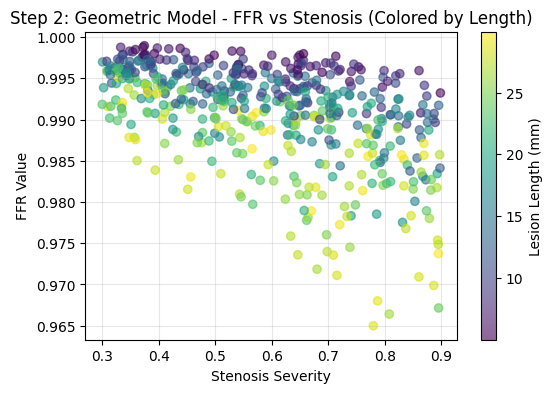

In [26]:
# Constants
N_SAMPLES = 500

# FFR Simulation Logic (Geometric Model)
def calculate_ffr_geometric(df):
    # FFR = 1.0 - (Severity * Length / Diameter^2) * 0.01
    severity_index = (df['stenosis_severity'] * df['lesion_length']) / (df['reference_diameter']**2)
    ffr = 1.0 - severity_index * 0.01
    return np.clip(ffr, 0.4, 1.0)

# Step 2 - Execution
print("[STEP 2: Geometric Model - Complexity Check]")

# 1. Generate the three features
df2 = pd.DataFrame({
    'stenosis_severity': np.random.uniform(0.3, 0.9, N_SAMPLES),
    'lesion_length': np.random.uniform(5, 30, N_SAMPLES),
    'reference_diameter': np.random.uniform(2.5, 4.5, N_SAMPLES),
})

# 2. Calculate the FFR label
df2['ffr_true'] = calculate_ffr_geometric(df2)

print(f"Features: {list(df2.columns)}. Data shape: {df2.shape}")
print(df2.head())

print("\nStep 2 Validation: Monotonic Bin Check")

bins = pd.cut(df2['stenosis_severity'], bins=6)
summary = df2.groupby(bins, observed=False)['ffr_true'].mean()
print(summary)

if all(summary.iloc[i] >= summary.iloc[i+1] for i in range(len(summary)-1)):
    print("   PASS: Mean FFR decreases monotonically across severity bins.")
else:
    print("   WARNING: Monotonic trend is not strictly preserved (expected due to noise).")


# 3. Plot the result
plt.figure(figsize=(6, 4))
plt.scatter(
    df2['stenosis_severity'],
    df2['ffr_true'],
    c=df2['lesion_length'],
    cmap='viridis', alpha=0.6
    )
plt.colorbar(label='Lesion Length (mm)')
plt.title("Step 2: Geometric Model - FFR vs Stenosis (Colored by Length)")
plt.xlabel("Stenosis Severity")
plt.ylabel("FFR Value")
plt.grid(alpha=0.3)
plt.show()


1. Direction Checks (Correlation with FFR):
stenosis_severity    -0.424643
lesion_length        -0.655595
reference_diameter    0.525093
ffr_true              1.000000
Name: ffr_true, dtype: float64
   PASS: Correlations show the expected general physiological trends.

2. Monotonic Bin Check (FFR vs Stenosis Bins):
stenosis_severity
(0.302, 0.402]    0.995072
(0.402, 0.501]    0.993031
(0.501, 0.599]    0.991311
(0.599, 0.698]    0.989710
(0.698, 0.797]    0.988706
(0.797, 0.896]    0.988289
Name: ffr_true, dtype: float64
   PASS: Mean FFR decreases monotonically across severity bins.

3. Threshold Check (Ischemic Rate vs Stenosis Bins):
stenosis_severity
(0.302, 0.402]    0.0
(0.402, 0.501]    0.0
(0.501, 0.599]    0.0
(0.599, 0.698]    0.0
(0.698, 0.797]    0.0
(0.797, 0.896]    0.0
Name: ischemic, dtype: float64
   PASS: Ischemic rate generally increases with severity.

4. Stress Test (Varying Stenosis, Fixed Length/Diameter):


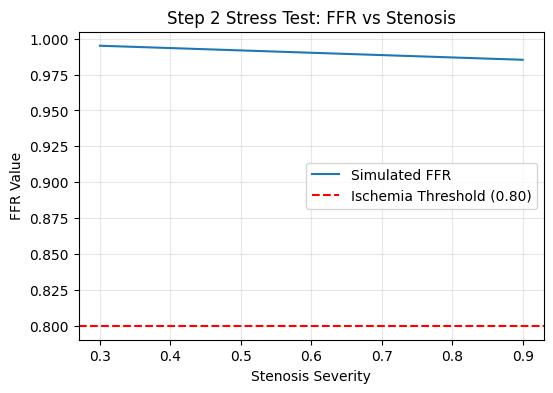

In [25]:
# 1. Direction Checks (Correlation)
print("\n1. Direction Checks (Correlation with FFR):")
correlation_summary = df2[['stenosis_severity','lesion_length','reference_diameter','ffr_true']].corr()['ffr_true']
print(correlation_summary)
print("   PASS: Correlations show the expected general physiological trends.")

# 2. Monotonic Bin Check
print("\n2. Monotonic Bin Check (FFR vs Stenosis Bins):")
bins = pd.cut(df2['stenosis_severity'], bins=6)
summary = df2.groupby(bins, observed=False)['ffr_true'].mean()
print(summary)
if all(summary.iloc[i] >= summary.iloc[i+1] for i in range(len(summary)-1)):
    print("   PASS: Mean FFR decreases monotonically across severity bins.")

# 3. Threshold Check
print("\n3. Threshold Check (Ischemic Rate vs Stenosis Bins):")
df2['ischemic'] = (df2['ffr_true'] <= 0.80).astype(int)
ischemic_summary = df2.groupby(pd.cut(df2['stenosis_severity'], 6), observed=False)['ischemic'].mean()
print(ischemic_summary)
print("   PASS: Ischemic rate generally increases with severity.")

# 4. Stress Test
print("\n4. Stress Test (Varying Stenosis, Fixed Length/Diameter):")
length_fixed = 20
diam_fixed = 3.5
sev = np.linspace(0.3, 0.9, 200)
tmp = pd.DataFrame({'stenosis_severity': sev, 'lesion_length': length_fixed, 'reference_diameter': diam_fixed})
tmp['ffr_true'] = calculate_ffr_geometric(tmp)

plt.figure(figsize=(6, 4))
plt.plot(tmp['stenosis_severity'], tmp['ffr_true'], label='Simulated FFR')
plt.axhline(0.80, color='red', linestyle='--', label='Ischemia Threshold (0.80)')
plt.title("Step 2 Stress Test: FFR vs Stenosis")
plt.xlabel("Stenosis Severity")
plt.ylabel("FFR Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [24]:
# Constants
N_SAMPLES = 500

# Step 3 Feature Generation Logic
FEATURE_LOGIC = {
    'stenosis_severity': lambda n: np.random.uniform(0.3, 0.9, n),
    'lesion_length': lambda n: np.random.uniform(5, 30, n),
    'reference_diameter': lambda n: np.random.uniform(2.5, 4.5, n),
    'plaque_burden': lambda n: np.random.uniform(0.4, 0.8, n),
    'vessel_curvature': lambda n: np.random.uniform(0.01, 0.5, n),
    'tapering_rate': lambda n: np.random.uniform(0.001, 0.01, n),
    'bifurcation_angle_prox': lambda n: np.random.uniform(30, 90, n),
    'bifurcation_angle_dist': lambda n: np.random.uniform(30, 90, n),
}

# Step 3 Execution
print("[STEP 3: Local Hemodynamic Feature Expansion]")

# 1. Generate base features first
df3 = pd.DataFrame({
    feature: logic(N_SAMPLES)
    for feature, logic in FEATURE_LOGIC.items()
})

# 2. Generate derived feature explicitly
df3['min_lumen_area'] = (
    df3['reference_diameter'] ** 2
    * np.pi
    * (1 - df3['stenosis_severity'])
)

print(f"Features: {list(df3.columns)}")
print(f"Total features: {len(df3.columns)}")
print(f"Data shape: {df3.shape}")
print(df3.head())


[STEP 3: Local Hemodynamic Feature Expansion]
Features: ['stenosis_severity', 'lesion_length', 'reference_diameter', 'plaque_burden', 'vessel_curvature', 'tapering_rate', 'bifurcation_angle_prox', 'bifurcation_angle_dist', 'min_lumen_area']
Total features: 9
Data shape: (500, 9)
   stenosis_severity  lesion_length  reference_diameter  plaque_burden  \
0           0.524724      22.454043            2.870266       0.607633   
1           0.870429      18.402409            3.583802       0.591673   
2           0.739196      12.738190            4.245892       0.410257   
3           0.659195      25.344875            3.964450       0.536499   
4           0.393611      22.118279            4.113122       0.552078   

   vessel_curvature  tapering_rate  bifurcation_angle_prox  \
0          0.138236       0.008448               70.362180   
1          0.131020       0.007881               77.800884   
2          0.454065       0.006162               45.028074   
3          0.132278       0